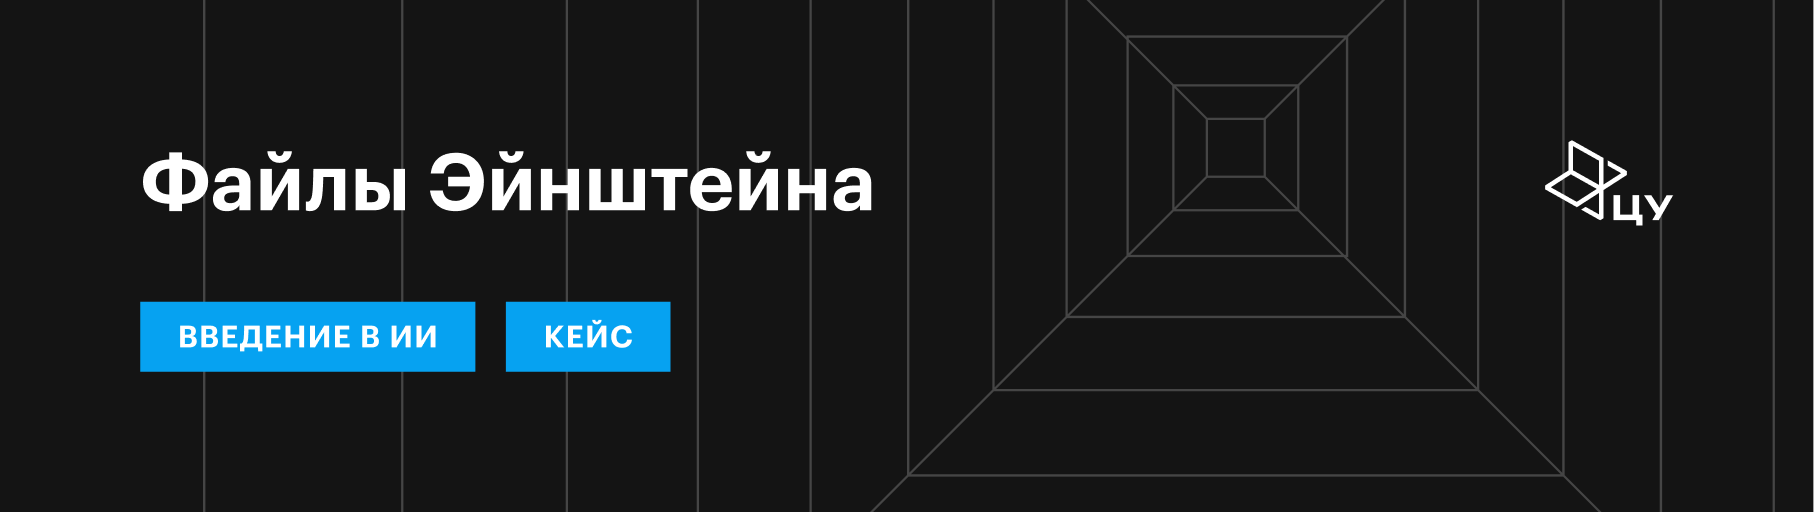

# Легенда

Ты работаешь в компании Х, которая занимается исследованием и сортировкой документов.
Недавно к тебе в руки попал ранее скрытый от глаз общественности материал *«Файлы Эйнштейна»*, содержащий тексты писем, написанных от руки великим учёным.

Один стажёр уже отсканировал файлы и начал вручную их расшифровывать. Однако старый офисный сканер оставил ошибки и артефакты на текстах, а вкупе с неразборчивым почерком Альберта Эйнштейна эта задача оказалась невыполнимой.

Поэтому твой начальник обратился к тебе с просьбой: «Сделайте так, чтобы компьютер сам всё прочитал. И чтобы потом можно было найти слово «бомба» или «антивселенная»: мало ли что там у этого Эйнштейна было на уме».

**Задача:** создать нейросетевую модель OCR (оптическое распознавание символов), которая сможет распознавать рукописный текст Эйнштейна с максимальной точностью.

# Требования к решению

Поскольку это учебный проект, вводятся следующие технические ограничения.

* **Ограничение по размеру модели:** решение должно корректно работать в Google Colab. Использовать несколько Google-аккаунтов для увеличения квоты на Т4 для экспериментов с архитектурой не запрещено.

* **Воспроизводимость:** весь код должен выполняться последовательно с первого раза. Обязательно фиксируй random_seed, а также сохраняй веса моделей и логируй эксперимент.

**Необходимые этапы решения**

1. *Обработка данных*. Внимательно изучи данные в датасете `einstein_files`. Предложи способ выделения символов из текста. Подумай, можно ли применять модель к сырым данным или нужно провести некоторые манипуляции.


2. *Выбор модели*. Напиши свою модель классификации рукописных букв английского алфавита или выбери предобученную.


3. *Решение задачи распознавания символов*. Обучение выбранной модели на датасете. Опиши, как осуществлялись подбор гиперпараметров, выбор метрики и валидация.

4. *Применение модели*. Финальный этап решения: объедини две основные составляющие в одну (выделение символов из изображения, их обработка моделью распознавания символов, составление полного текста). Результаты OCR будут проверяться по метрикам accuracy.

# Система оценивания

Решение оценивается по трём параметрам.
* **Работа с данными [4 балла].** Оценка ставится в соответствии с тем, насколько подробно была произведена работа с данными. Визуализации, предобработка и очистка/обогащение датасета будут плюсом.

* **Решение задачи [4 балла].** Оценка ставится не за итоговые метрики (для простых моделей их значение может быть небольшим), а за то, насколько качественно были проделаны эксперименты в рамках выбранной модели. То есть если в решении используется примитивная модель, получающая низкие метрики, но она обучена с разными гиперпараметрами и приёмами так, что из её качества выжимается максимум, то это решение будет оценено в полный балл.

* **Оформление [2 балла].** Хочется, чтобы написанный код читался как хорошая книга. Для этого мы добавляем баллы за оформление, если в коде появляются визуализации, комментарии к коду и сопроводительный текст.

# Данные

Ниже написан код для скачивания датасета `einstien_files`, который содержит 46 изображений отсканированных документов с рукописным текстом на английском языке.

In [ ]:
!gdown 1gMlho_Jrzuy2Lt-8rKZa8gr7jo_RiMUQ
!unzip -q /content/einstein_files.zip
!rm /content/einstein_files.zip

Downloading...
From: https://drive.google.com/uc?id=1gMlho_Jrzuy2Lt-8rKZa8gr7jo_RiMUQ
To: /content/einstein_files.zip
100% 4.81M/4.81M [00:00<00:00, 134MB/s]


# Твой код

EDA

Загрузка и первичная визуализация

Сохраним все в одном пространстве

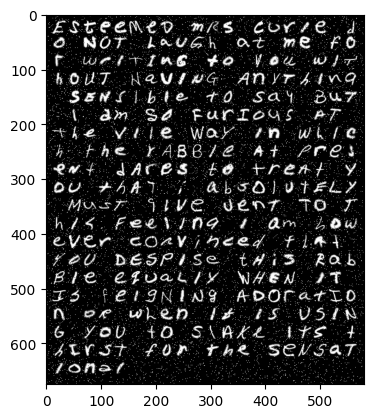

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

example_path = '/content/einstein_files/file_0.png'
imgs = cv2.imread(example_path)

plt.imshow(imgs)
plt.show()

In [ ]:
data_path = '/content/einstein_files/'
file_names = [f for f in os.listdir(data_path) if f.endswith('.png')]
file_names.sort(key=lambda x: int(x.split('_')[1].split('.')[0]))
print(f'Наши файлы: {file_names}')

Наши файлы: ['file_0.png', 'file_1.png', 'file_2.png', 'file_3.png', 'file_4.png', 'file_5.png', 'file_6.png', 'file_7.png', 'file_8.png', 'file_9.png', 'file_10.png', 'file_11.png', 'file_12.png', 'file_13.png', 'file_14.png', 'file_15.png', 'file_16.png', 'file_17.png', 'file_18.png', 'file_19.png', 'file_20.png', 'file_21.png', 'file_22.png', 'file_23.png', 'file_24.png', 'file_25.png', 'file_26.png', 'file_27.png', 'file_28.png', 'file_29.png', 'file_30.png', 'file_31.png', 'file_32.png', 'file_33.png', 'file_34.png', 'file_35.png', 'file_36.png', 'file_37.png', 'file_38.png', 'file_39.png', 'file_40.png', 'file_41.png', 'file_42.png', 'file_43.png', 'file_44.png', 'file_45.png']


Загрузим все в единый массив

Форма нового массива: (46, 580, 675)


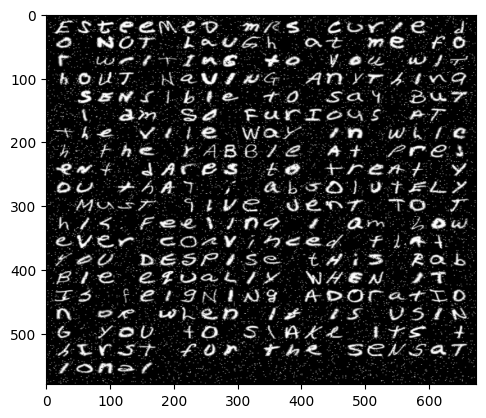

In [ ]:
images_list = []
target_size = (675,580)

for name in file_names:
  full_path = os.path.join(data_path, name)
  img = cv2.imread(full_path,cv2.IMREAD_GRAYSCALE)
  if img is not None:
    img_resized = cv2.resize(img, target_size)
    images_list.append(img_resized)

all_images = np.array(images_list)
print('Форма нового массива:',all_images.shape)
plt.imshow(all_images[0],cmap='gray')

In [ ]:
import glob
print(f'Всего файлов: {len(all_images)}')
all_files = glob.glob('/content/einstein_files/*.png')
shapes = [cv2.imread(f,0).shape for f in all_files[:5]]
print(f'Примеры размеров (H,w): {shapes}')

Всего файлов: 46
Примеры размеров (H,w): [(675, 580), (675, 580), (675, 580), (675, 580), (675, 580)]


Мы видим ошибки офисного сканера, соль и перец присусвует на картинке

Покажем статистику датасета

Нарисуем распределение размеров картинок

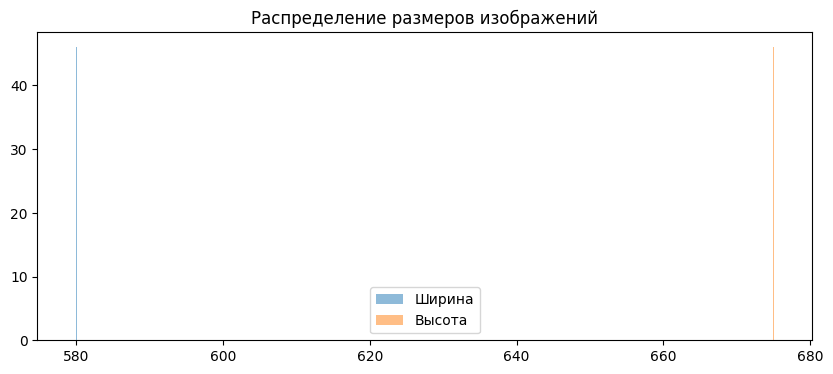

In [ ]:
widths = [cv2.imread(f, 0).shape[1] for f in all_files]
heights = [cv2.imread(f, 0).shape[0] for f in all_files]

plt.figure(figsize=(10, 4))
plt.hist(widths, bins=20, alpha=0.5, label='Ширина')
plt.hist(heights, bins=20, alpha=0.5, label='Высота')
plt.legend()
plt.title("Распределение размеров изображений")
plt.show()

Нарисуем гистограммы распределения пикселей

/tmp/ipykernel_1868/611159331.py:7: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(sample_img.ravel(), 256, [0, 256])


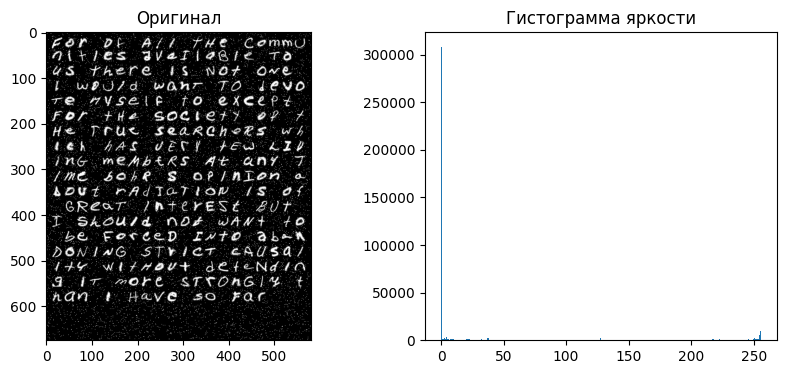

In [ ]:
sample_img = cv2.imread(all_files[0],0)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(sample_img, cmap='gray')
plt.title("Оригинал")
plt.subplot(1, 2, 2)
plt.hist(sample_img.ravel(), 256, [0, 256])
plt.title("Гистограмма яркости")
plt.show()


Анализ гистограммы показывает, что данные имеют высокую контрастность, однако присутствуют шумы в темных областях

Не забудем привести в порядок картинки

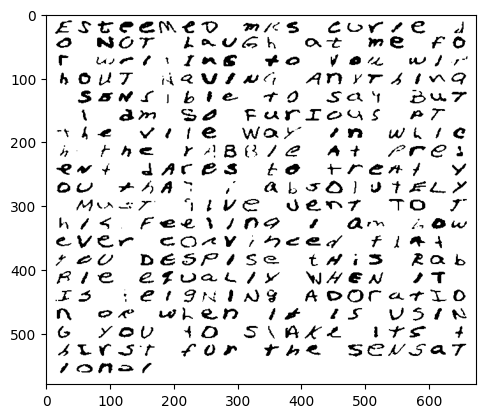

In [ ]:
def clean_image(img):
  if img.dtype!=np.uint8:
    img = (img*255).astype(np.uint8)
  cleaned = cv2.medianBlur(img, 3)
  _,binary = cv2.threshold(cleaned,127,255,cv2.THRESH_BINARY_INV)
  return binary



cleaned_images = np.array([clean_image(img) for img in all_images])
plt.imshow(cleaned_images[0],cmap='gray')

Разница до/после видна нагляднейшим образом

Перейдем теперь к сбору датасета на котором наша CNN будет обучаться, возьмем EMNIST

In [ ]:
#Импорты
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [ ]:
torch.manual_seed(42)

#Так как в EMNIST все не как у людей, нужно повернуть на 90 и отзеркалить
transform = transforms.Compose([transforms.ToTensor(),lambda x:x.transpose(1,2),transforms.Normalize((0.5,),(0.5,))])

#Загрузим train и test
train_dataset = datasets.EMNIST(root = './data', split = 'letters', train = True, download = True, transform = transform)
test_dataset = datasets.EMNIST(root = './data', split = 'letters', train = False, download = True, transform = transform)

train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 64, shuffle = False)
print(len(train_dataset))

100%|██████████| 562M/562M [00:05<00:00, 108MB/s]


124800


124800 изображений у нас есть для обучения

Теперь напишем модель

In [ ]:
class EinsteinOCRModel(nn.Module):
  def __init__(self):
    super(EinsteinOCRModel, self).__init__()
    self.conv1 = nn.Conv2d(1,32,kernel_size=3,padding = 1)
    self.relu1 = nn.ReLU()
    self.pool1 = nn.MaxPool2d(2)

    self.conv2 = nn.Conv2d(32,64,kernel_size=3,padding = 1)
    self.relu2 = nn.ReLU()
    self.pool2 = nn.MaxPool2d(2)

    self.flatten = nn.Flatten()
    self.fc1 = nn.Linear(64*7*7,128)
    self.dropout = nn.Dropout(0.2)
    self.fc2 = nn.Linear(128,27)
  def forward(self,x):
    x = self.pool1(self.relu1(self.conv1(x)))
    x = self.pool2(self.relu2(self.conv2(x)))
    x = self.flatten(x)
    x = torch.relu(self.fc1(x))
    x = self.dropout(x)
    x = self.fc2(x)
    return x




model = EinsteinOCRModel()

Настроим обучение

In [ ]:
criterion = nn.CrossEntropyLoss()#база для задач классификации
optimizer = optim.Adam(model.parameters(), lr = 0.001)#он просто крут, вася писляков сказал

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
EPOCHS = 10
history = {'train_loss':[],'test_acc':[]}
model.to(device)

EinsteinOCRModel(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=128, out_features=27, bias=True)
)

Обучение

In [ ]:
def train():
  model.train()
  train_loss = 0
  correct = 0
  total = 0
  for batch_idx,(data,target) in enumerate(train_loader):
    data, target = data.to(device), target.to(device)
    optimizer.zero_grad()
    output = model(data)
    loss = criterion(output,target)
    loss.backward()
    optimizer.step()

    train_loss += loss.item()
    _, predicted = output.max(1)
    total += target.size(0)
    correct += predicted.eq(target).sum().item()
  return train_loss/len(train_loader),100*correct/total
def test():
  model.eval()
  correct = 0
  total = 0
  with torch.no_grad():
    for data, target in test_loader:
      data,target = data.to(device),target.to(device)
      output = model(data)
      _,predicted = output.max(1)
      total += target.size(0)
      correct += predicted.eq(target).sum().item()
  return 100.*correct/total

Запуск и сохранение логов

In [ ]:
import tqdm
for epoch in tqdm.tqdm(range(1,EPOCHS+1)):
  avg_loss,train_acc = train()
  test_acc = test()
  history['train_loss'].append(avg_loss)
  history['test_acc'].append(test_acc)
  print(f'Эпоха: {epoch:02d} | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}% ')


torch.save(model.state_dict(),'einstein_ocr_model.pth')


 10%|█         | 1/10 [00:39<05:54, 39.38s/it]

Эпоха: 01 | Loss: 0.5976 | Train Acc: 81.38% | Test Acc: 90.83% 


 20%|██        | 2/10 [01:17<05:08, 38.54s/it]

Эпоха: 02 | Loss: 0.3204 | Train Acc: 89.71% | Test Acc: 91.80% 


 30%|███       | 3/10 [01:54<04:25, 37.95s/it]

...

Эпоха: 08 | Loss: 0.1689 | Train Acc: 94.05% | Test Acc: 93.67% 


 90%|█████████ | 9/10 [05:37<00:37, 37.15s/it]

Эпоха: 09 | Loss: 0.1587 | Train Acc: 94.33% | Test Acc: 93.73% 


100%|██████████| 10/10 [06:14<00:00, 37.41s/it]

Эпоха: 10 | Loss: 0.1471 | Train Acc: 94.67% | Test Acc: 93.66% 


# Итог

В этом разделе мы подведём итоги обработки данных и обучения модели OCR. Для этого мы используем две метрики — **Character Error Rate** (CER) и **Word Error Rate** (WER).

1. CER вычисляется как расстояние Левенштейна (то есть количество замен символов, необходимое для перевода одной строки в другую) между исходным текстом и распознанным, делённое на количество символов.

2. WER вычисляется как процент совпадающих слов.

In [ ]:
!pip install Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 120.1 MB/s eta 0:00:00


In [ ]:
from Levenshtein import distance

def character_error_rate(pred_text, real_text):
    """Расстояние Левенштейна"""
    return distance(pred_text, real_text) / len(real_text)

In [ ]:
def word_error_rate(pred_text, real_text):
    """Процент слов, распознанных с ошибкой"""
    pred_words = pred_text.split()
    true_words = real_text.split()

    if len(true_words) == 0:
        return 0 if len(pred_words) == 0 else 1.0

    errors = sum(1 for p, t in zip(pred_words, true_words) if p != t)
    errors += abs(len(pred_words) - len(true_words))

    return errors / len(true_words)

Напиши функцию для обработки файлов Эйнштейна. Она должна принимать на вход датасет `epstein_files` (чтение данных и их обработку ты выбираешь и реализовываешь самостоятельно) и твою модель OCR `model`. На выходе — распознанный текст.

In [ ]:
def process(folder_path,model,device):
    # Твой код здесь
    file_list = glob.glob(os.path.join(folder_path, "*.png"))
    file_list.sort(key=lambda x: int(os.path.basename(x).split('_')[1].split('.')[0]))
    model.eval()
    full_text = []

    for file_path in file_list:
        img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
          continue
        cleaned = clean_image(img)
        contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        char_boxes = []
        for cnt in contours:
          x, y, w, h = cv2.boundingRect(cnt)
          if w > 5 and h > 10:
              char_boxes.append((x, y, w, h))
        char_boxes.sort(key=lambda b: b[0])
        current_word = ""
        for x,y,w,h in char_boxes:
          roi = cleaned[y:y+h,x:x+w]
          roi_resized = cv2.resize(roi,(28,28),interpolation = cv2.INTER_AREA)
          img_tensor = torch.from_numpy(roi_resized).float().unsqueeze(0).unsqueeze(0).to(device)
          img_tensor = img_tensor / 255.0  # Нормализация 0-1
          img_tensor = (img_tensor - 0.5) / 0.5  # Нормализация как в Transforms
          with torch.no_grad():
            output = model(img_tensor)
            _, predicted = torch.max(output, 1)
            char = chr(int(predicted.item()) + 64)
            current_word += char
        full_text.append(current_word.lower())
    return " ".join(full_text)


In [ ]:
path = '/content/einstein_files/'
pred_text = process(path, model, device)


Прочитай текстовый файл с реальным текстом файлов Эйнштейна и оцени качество модели с помощью метрик выше.

**ВНИМАНИЕ.** Данный файл в целях академической честности может быть прочтён и использован только в части кода снизу.

In [ ]:
!gdown 1hF7HHyIROhPoVOzQnBiqjfYtJ6v4raJC

Downloading...
From: https://drive.google.com/uc?id=1hF7HHyIROhPoVOzQnBiqjfYtJ6v4raJC
To: /content/top_secret.txt
100% 15.4k/15.4k [00:00<00:00, 51.8MB/s]


In [ ]:
with open('top_secret.txt', 'r', encoding='utf-8') as file:
    real_text = file.read().lower()

In [ ]:
wer = word_error_rate(pred_text, real_text)
cer = character_error_rate(pred_text, real_text)
print(f"WER = {wer}")
print(f"CER = {cer}")

WER = 1.0
CER = 0.9953201169970751


**Выводы:** опиши, как ты пришёл(-ла) к решению, какие модели использовались, как проходил подбор гиперпараметров, как работал(а) с данными, с какими проблемами столкнулся(ась) и прочее.

В ходе EDA я выснил несколько проблем: высокочастотный шум и низкую контрастность. Для решения этого и использовал медианный фильтр для удаления высококочастоного шума и сделал бинаризацию для хорошего поиска контуров.

В качестве сети я выбрал CNN, с нелинейной функцией активации, пулингом и дропаутом. Модель обучалась на датасете EMNIST, обучилось в итоге хорошо).

Оптимизатор я выбрал по советам Васи Пислякова, респект ему, функцию потерь выбрал CrossEntropyLoss, описал почему. Основной проблемой стал курсивный почерк, могла возникать проблема лсишком сильного сболижение букв, что вызывает сбой в сегметнации.